In [1]:
#importing packages
import nibabel as nib
import numpy as np
from nilearn import datasets, image
import matplotlib.pyplot as plt

In [2]:
file_path = r"\Users\ikong\OneDrive\Documents\Fysikk Master\Vår 2026\PHYS291\data\rfMRI_REST1_LR_hp2000_clean_rclean_tclean.nii"

img = nib.load(file_path) # Load the file
data = img.get_fdata() # Convert to numpy array
header = img.header # View header metadata

In [3]:
data.shape

(91, 109, 91, 1200)

The data takes the form: (x, y, z, t)

In [4]:
header.get_xyzt_units()

('mm', 'sec')

In [5]:
type(data)

numpy.memmap

type memmap because the the file is too large for my RAM to handle. 

In [6]:
raw = header.structarr
raw['xyzt_units']

array(10, dtype=uint8)

In [7]:
print(header)

<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b''
dim_info        : 0
dim             : [   4   91  109   91 1200    1    1    1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : float32
bitpix          : 32
slice_start     : 0
pixdim          : [-1.    2.    2.    2.    0.72  0.    0.    0.  ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Connectome Workbench, version 1.5.0'
aux_file        : b''
qform_code      : mni
sform_code      : mni
quatern_b       : 0.0
quatern_c       : 1.0
quatern_d       : 0.0
qoffset_x       : 90.0
qoffset_y       : -126.0
qoffset_z    

In [8]:
#getting voxel sizes in mm
header.get_zooms()

(2.0, 2.0, 2.0, 0.72)

The voxels have volumes of 2 mm^3, and there are 0.72 seconds between each scan

I want now to transform the data from voxel space to (brain) region space. This is done by overlaying an atlas, which defines which voxels belongs to which region, and summing their entry region wise. In that way, we reduce the data size massively.

In [11]:
# Load a standard atlas 
atlas = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_filename = atlas.maps
#atlas_img = nib.load(atlas_filename)
#atlas_data = atlas_img.get_fdata()

[fetch_atlas_harvard_oxford] Dataset found in C:\Users\ikong\nilearn_data\fsl


In [12]:
from nilearn.maskers import NiftiLabelsMasker

# Initialize the masker with the atlas
masker = NiftiLabelsMasker(labels_img=atlas_filename, 
                           standardize=True, 
                           verbose=1)


In [13]:
# Extract the time series
time_series = masker.fit_transform(img)
# time_series shape: (number of timepoints, number of regions)

[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x000002369F1853F0>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit


C:\Users\ikong\AppData\Local\Temp\ipykernel_30496\4071463355.py:2: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  time_series = masker.fit_transform(img)


[NiftiLabelsMasker.wrapped] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000002369C949810>
[NiftiLabelsMasker.wrapped] Extracting region signals
[NiftiLabelsMasker.wrapped] Cleaning extracted signals


In [14]:
time_series.shape

(1200, 48)

Have now transformed the data into 48 physiologigal brain regions, measured at 1200 instances in time.

In [ ]:
atlas.lut

,index,name
0,0,Background
1,1,Frontal Pole
2,2,Insular Cortex
3,3,Superior Frontal Gyrus
4,4,Middle Frontal Gyrus
5,5,"Inferior Frontal Gyrus, pars triangularis"
6,6,"Inferior Frontal Gyrus, pars opercularis"
7,7,Precentral Gyrus
8,8,Temporal Pole
9,9,"Superior Temporal Gyrus, anterior division"


In [ ]:
#showing the first row of data 
time_series[0]

array([ 3.9913285 ,  0.3993136 ,  4.696585  ,  4.403254  ,  2.1907067 ,
        2.8240342 ,  1.4638146 ,  0.6370966 , -0.49395466, -1.8256714 ,
       -0.59854543,  2.4370406 ,  1.7971635 , -1.0910531 ,  0.12398763,
        0.51359034,  2.4757357 ,  3.8873737 ,  1.1733224 ,  2.4440348 ,
        2.6512897 ,  3.6440156 ,  2.7163246 ,  0.9245108 , -1.4732658 ,
        0.82889193, -0.06901232,  0.4884667 ,  1.7321365 ,  0.53362626,
        1.61007   ,  2.0223246 ,  0.87535113,  0.20997995, -0.46774796,
        1.5694983 ,  0.5181304 , -1.6242065 ,  0.7530256 ,  1.9310625 ,
        0.8759269 , -0.13092598,  0.07029256, -0.9405684 , -0.95970863,
       -1.803885  ,  1.3859743 ,  2.213838  ], dtype=float32)

DMN network hub: Posterior Cingulate Cortex, here called: Cingulate Gyrus, posterior division

In [15]:
#i want to fetch just this region

PCC = time_series[:, 30]
PCC.shape
PCC

array([1.61007   , 0.6326364 , 0.40655226, ..., 1.1234053 , 1.9708397 ,
       2.2373269 ], dtype=float32)

In [ ]:
#visualize the data from one brain region over time
def plot_region(region_n):
    region_data = time_series[:, region_n]
    region_name = atlas.labels[region_n]

    plt.plot(region_data)
    plt.xlabel("Time")
    plt.ylabel('Signal amplitude')
    plt.title(f"{region_name} signal over time")
    plt.show()

    region_median = np.median( abs(region_data) )
    print(f"Median value of {region_name}:  {region_median}")

Plotting a region that i would expect to be very active

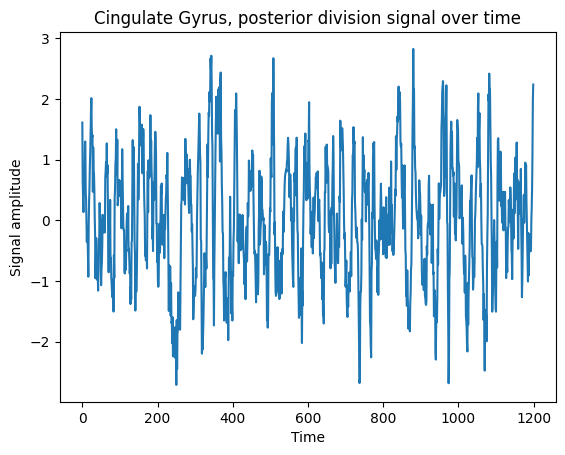

Median value of Cingulate Gyrus, posterior division:  0.7066205739974976


In [42]:
plot_region(30)

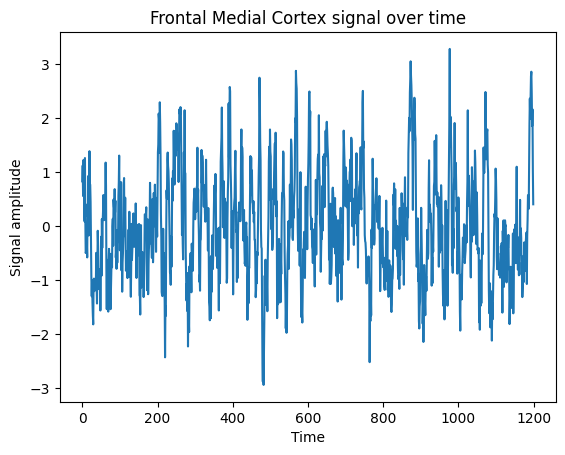

Median value of Frontal Medial Cortex:  0.6824101209640503


In [43]:
#Frontal Medial Cortex
plot_region(25)

Plotting a region that i would expect to have low activity

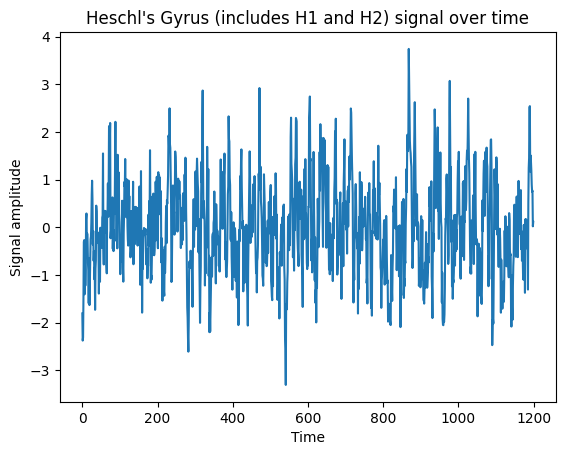

Median value of Heschl's Gyrus (includes H1 and H2):  0.6693935394287109


In [ ]:
#Heschl's Gyrus
plot_region(45)